In [1]:
import pickle
import os
import gpflow
import numpy as np
from tensorflow_probability import distributions as tfd
from s0_fun_base import XY_grw_nf_compu, XY_grw_f_compu, XY_sur_compu, XY_fec_compu, XY_flow_compu
from s0_class_ABCPMC import ipmmcmc_whole
from s0_fun_IBMs import popu_structure
f64 = gpflow.utilities.to_default_float
import matplotlib.pylab as plt
import pandas as pd
import bambi as bmb
from matplotlib.ticker import MaxNLocator

truedata_style='gp'
popu_dataset = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/"+truedata_style+"_mle_true_population.pkl", mode="rb"))
models_true = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/gp_"+truedata_style+"mle_mle_models.pkl", mode="rb"))

samples_grw_f = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_f.pkl", mode="rb"))
samples_grw_nf = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_nf.pkl", mode="rb"))
samples_sur = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_sur.pkl", mode="rb"))
samples_flow = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_flow.pkl", mode="rb"))
samples_fec = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_fec.pkl", mode="rb"))



In [2]:
#setting
truedata_style='gp'
grw_setting='sep'
model_type = 'gpabc'

#Loading data
samples_grw_f = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_f.pkl", mode="rb"))
samples_grw_nf = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_grw_nf.pkl", mode="rb"))
samples_sur = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_sur.pkl", mode="rb"))
samples_flow = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_flow.pkl", mode="rb"))
samples_fec = pickle.load(open(file = os.getcwd()+f"/true_popu/"+truedata_style+"_mle_true_population/MCMC/gp/sep/samples_fec.pkl", mode="rb"))
gp_mle_true_population = pickle.load(open(file = os.getcwd()+f"/true_popu/gp_mle_true_population/gp_mle_true_population.pkl", mode="rb"))
popu_dataset = globals()[f'{truedata_style}_mle_true_population']

# Fec
df_fec = XY_fec_compu(popu_dataset)  
m_fec_new = gpflow.models.GPMC(data=(df_fec[0], df_fec[1]), 
                            kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

m_fec_new.kernel.variance.prior = tfd.InverseGamma(f64(0.001),f64(0.001))
m_fec_new.kernel.lengthscales.prior = tfd.Normal(loc=f64(0.), scale=f64(100.))
hmc_helper_fec = gpflow.optimizers.SamplingHelper(
    m_fec_new.log_posterior_density, m_fec_new.trainable_parameters
)


# Flow poi
df_flow = XY_flow_compu(popu_dataset)  
m_flow_poi_new =  gpflow.models.GPMC(data=(df_flow[0], df_flow[1]), 
                                kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Poisson())
m_flow_poi_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
m_flow_poi_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
hmc_helper_flow = gpflow.optimizers.SamplingHelper(
    m_flow_poi_new.log_posterior_density, m_flow_poi_new.trainable_parameters
)



# Grw_f
df_grw_f = XY_grw_f_compu(popu_dataset)    
m_grw_f_new = gpflow.models.GPR(data=(df_grw_f[0], df_grw_f[1]), kernel=gpflow.kernels.RBF())
m_grw_f_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
m_grw_f_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
m_grw_f_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
hmc_helper_grw_f = gpflow.optimizers.SamplingHelper(
    m_grw_f_new.log_posterior_density, m_grw_f_new.trainable_parameters
)



# Grw_nf
df_grw_nf = XY_grw_nf_compu(popu_dataset)    
m_grw_nf_new = gpflow.models.GPR(data=(df_grw_nf[0], df_grw_nf[1]), kernel=gpflow.kernels.RBF())
m_grw_nf_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(100.))
m_grw_nf_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(100.))
m_grw_nf_new.likelihood.variance.prior = tfd.HalfNormal(scale=f64(100.))
hmc_helper_grw_nf = gpflow.optimizers.SamplingHelper(
    m_grw_nf_new.log_posterior_density, m_grw_nf_new.trainable_parameters
)



# Sur
df_sur = XY_sur_compu(popu_dataset)  
m_sur_new = gpflow.models.GPMC(data=(df_sur[0], df_sur[1]), 
                            kernel=gpflow.kernels.RBF(), likelihood=gpflow.likelihoods.Bernoulli())

m_sur_new.kernel.lengthscales.prior = tfd.HalfNormal(scale=f64(50.))
m_sur_new.kernel.variance.prior = tfd.HalfNormal(scale=f64(50.))
hmc_helper_sur = gpflow.optimizers.SamplingHelper(
    m_sur_new.log_posterior_density, m_sur_new.trainable_parameters
)



In [3]:
# define a fucntion to extract hyper-parameter values in the MCMC samples
para_names_whole = ['sur_lsize', 'sur_kvar',
                    'grwf_lsize', 'grwf_kvar', 'grwf_lvar',
                    'grwnf_lsize', 'grwnf_kvar','grwnf_lvar',
                    'fec_lsize', 'fec_kvar',
                    'flowp_lsize', 'flowp_kvar']


def extract_parameters_whole(models):
    theta = pd.DataFrame(0, range(1), para_names_whole)

    theta['sur_lsize'] = np.array(models['m_sur'].kernel.lengthscales)
    theta['sur_kvar'] = np.array(models['m_sur'].kernel.variance)

    theta['grwf_lsize'] = np.array(models['m_grw_f'].kernel.lengthscales)
    theta['grwf_kvar'] = np.array(models['m_grw_f'].kernel.variance)
    theta['grwf_lvar'] = np.array(models['m_grw_f'].likelihood.variance) 
    
    theta['grwnf_lsize'] = np.array(models['m_grw_nf'].kernel.lengthscales)
    theta['grwnf_kvar'] = np.array(models['m_grw_nf'].kernel.variance)
    theta['grwnf_lvar'] = np.array(models['m_grw_nf'].likelihood.variance) 

    theta['fec_lsize'] = np.array(models['m_fec'].kernel.lengthscales)
    theta['fec_kvar'] = np.array(models['m_fec'].kernel.variance)

    theta['flowp_lsize'] = np.array(models['m_flow_poi'].kernel.lengthscales)
    theta['flowp_kvar'] = np.array(models['m_flow_poi'].kernel.variance)

    return theta

In [4]:
# extracting hyper-parameter values in the MCMC samples
re_extract = False
if re_extract == True:
    theta_MCMC = pd.DataFrame(0, range(5000), para_names_whole)
    nlp_MCMC = pd.DataFrame(0, range(5000), ["sur", "grw_f", "grw_nf", "fec", "flow_poi"])
    for i in range(5000):
        c_index = [i, i, i, i, i, i] 

        for var, var_samples in zip(hmc_helper_sur.current_state, samples_sur):
            var.assign(var_samples[c_index[0]])
        # grw_f
        for var, var_samples in zip(hmc_helper_grw_f.current_state, samples_grw_f):
            var.assign(var_samples[c_index[1]])
        # grw_nf
        for var, var_samples in zip(hmc_helper_grw_nf.current_state, samples_grw_nf):
            var.assign(var_samples[c_index[2]])
        # fec
        for var, var_samples in zip(hmc_helper_fec.current_state, samples_fec):
            var.assign(var_samples[c_index[3]])
        # flow
        for var, var_samples in zip(hmc_helper_flow.current_state, samples_flow):
            var.assign(var_samples[c_index[4]])


        models_now = {
            "m_sur": m_sur_new ,
            "m_grw_f": m_grw_f_new,
            "m_grw_nf": m_grw_nf_new ,
            "m_fec": m_fec_new,
            "m_flow_poi": m_flow_poi_new
        }
        
        theta_MCMC.iloc[i,:] = extract_parameters_whole(models_now)
        for kk in ["sur", "grw_f", "grw_nf", "fec", "flow_poi"]: 
            nlp_MCMC.loc[i,kk] = models_now['m_'+kk].log_posterior_density().numpy()
        

        min_indices = nlp_MCMC.idxmin()

        # Find the value of the hyper-parameetr corresponding to the minimum log-posterior density 
        # sur
        for var, var_samples in zip(hmc_helper_sur.current_state, samples_sur):
            var.assign(var_samples[min_indices['sur']])
        # grw_f
        for var, var_samples in zip(hmc_helper_grw_f.current_state, samples_grw_f):
            var.assign(var_samples[min_indices['grw_f']])
        # grw_nf
        for var, var_samples in zip(hmc_helper_grw_nf.current_state, samples_grw_nf):
            var.assign(var_samples[min_indices['grw_nf']])
        # fec
        for var, var_samples in zip(hmc_helper_fec.current_state, samples_fec):
            var.assign(var_samples[min_indices['fec']])
        # flow
        for var, var_samples in zip(hmc_helper_flow.current_state, samples_flow):
            var.assign(var_samples[min_indices['flow_poi']])


        models_now = {
            "m_sur": m_sur_new ,
            "m_grw_f": m_grw_f_new,
            "m_grw_nf": m_grw_nf_new ,
            "m_fec": m_fec_new,
            "m_flow_poi": m_flow_poi_new
        }

        theta_mini = extract_parameters_whole(models_now)
        pickle.dump(theta_MCMC, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/theta_MCMC.pkl", mode="wb"))
        pickle.dump(nlp_MCMC, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/nlp_MCMC.pkl", mode="wb"))
        pickle.dump(theta_mini, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/theta_mini.pkl", mode="wb"))
else:
    theta_MCMC = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/theta_MCMC.pkl", mode="rb"))
    nlp_MCMC = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/nlp_MCMC.pkl", mode="rb"))
    theta_mini = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/theta_mini.pkl", mode="rb"))


In [5]:
min_nlp_MCMC = np.min(nlp_MCMC, 0)

In [6]:
perturbation_kernel = {
    column: {
        "mean": theta_MCMC[column].mean(),
        "variance": theta_MCMC[column].var()
    }
    for column in theta_MCMC.columns
}

In [7]:
re_generate = False
if re_generate == True:
    # Repeat 5000 times
    absolute_differences = []
    absolute_differences_nlp = []
    # Set random seed
    np.random.seed(123456)

    # Repeat 100 times
    absolute_differences = []
    for _ in range(5000):
        # Generate perturbed values
        perturbed_values = {
            column: np.random.normal(
                loc=perturbation_kernel[column]["mean"],
                scale=np.sqrt(perturbation_kernel[column]["variance"])
            )
            for column in perturbation_kernel
        }
        
        # Assign perturbed values to GP models in models_now
        models_now['m_sur'].kernel.lengthscales.assign(abs(perturbed_values['sur_lsize']))
        models_now['m_sur'].kernel.variance.assign(abs(perturbed_values['sur_kvar']))

        models_now['m_grw_f'].kernel.lengthscales.assign(abs(perturbed_values['grwf_lsize']))
        models_now['m_grw_f'].kernel.variance.assign(abs(perturbed_values['grwf_kvar']))
        models_now['m_grw_f'].likelihood.variance.assign(abs(perturbed_values['grwf_lvar']))

        models_now['m_grw_nf'].kernel.lengthscales.assign(abs(perturbed_values['grwnf_lsize']))
        models_now['m_grw_nf'].kernel.variance.assign(abs(perturbed_values['grwnf_kvar']))
        models_now['m_grw_nf'].likelihood.variance.assign(abs(perturbed_values['grwnf_lvar']))

        models_now['m_fec'].kernel.lengthscales.assign(abs(perturbed_values['fec_lsize']))
        models_now['m_fec'].kernel.variance.assign(abs(perturbed_values['fec_kvar']))

        models_now['m_flow_poi'].kernel.lengthscales.assign(abs(perturbed_values['flowp_lsize']))
        models_now['m_flow_poi'].kernel.variance.assign(abs(perturbed_values['flowp_kvar']))

        # Calculate the sum of absolute differences
        sum_abs_diff = sum(
            abs(perturbed_values[column] - theta_mini[column].iloc[0])
            for column in perturbation_kernel
        )
        absolute_differences.append(sum_abs_diff)

        sum_abs_nlp = abs(models_now['m_sur'].log_posterior_density().numpy() - min_nlp_MCMC['sur'])
        sum_abs_nlp += abs(models_now['m_grw_f'].log_posterior_density().numpy() - min_nlp_MCMC['grw_f'])
        sum_abs_nlp += abs(models_now['m_grw_nf'].log_posterior_density().numpy() - min_nlp_MCMC['grw_nf'])
        sum_abs_nlp += abs(models_now['m_fec'].log_posterior_density().numpy() - min_nlp_MCMC['fec'])
        sum_abs_nlp += abs(models_now['m_flow_poi'].log_posterior_density().numpy() - min_nlp_MCMC['flow_poi'])
        absolute_differences_nlp.append(sum_abs_nlp)
        
        pickle.dump(absolute_differences, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences.pkl", mode="wb"))
        pickle.dump(absolute_differences_nlp, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences_nlp.pkl", mode="wb"))
else:
    # Load the absolute differences
    absolute_differences = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences.pkl", mode="rb"))
    absolute_differences_nlp = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences_nlp.pkl", mode="rb"))

In [8]:
re_generate = False
if re_generate == True:
    # Repeat 5000 times
    absolute_differences = []
    absolute_differences_nlp = []
    # Set random seed
    np.random.seed(123456)

    # Repeat 100 times
    absolute_differences = []
    for _ in range(5000):
        # Generate perturbed values
        perturbed_values = {
            column: np.random.normal(
                loc=perturbation_kernel[column]["mean"],
                scale=np.sqrt(perturbation_kernel[column]["variance"])
            )
            for column in perturbation_kernel
        }
        
        # Assign perturbed values to GP models in models_now
        models_now['m_sur'].kernel.lengthscales.assign(abs(perturbed_values['sur_lsize']))
        models_now['m_sur'].kernel.variance.assign(abs(perturbed_values['sur_kvar']))
        # Set the lengthscales and variance parameters as non-trainable
        gpflow.set_trainable(models_now['m_sur'].kernel.lengthscales, False)
        gpflow.set_trainable(models_now['m_sur'].kernel.variance, False)
        # optimize parameters used for approximation
        opt = gpflow.optimizers.Scipy()
        opt.minimize(models_now['m_sur'].training_loss, models_now['m_sur'].trainable_variables)

        models_now['m_fec'].kernel.lengthscales.assign(abs(perturbed_values['fec_lsize']))
        models_now['m_fec'].kernel.variance.assign(abs(perturbed_values['fec_kvar']))
        gpflow.set_trainable(models_now['m_fec'].kernel.lengthscales, False)
        gpflow.set_trainable(models_now['m_fec'].kernel.variance, False)
        opt.minimize(models_now['m_fec'].training_loss, models_now['m_fec'].trainable_variables)

        models_now['m_flow_poi'].kernel.lengthscales.assign(abs(perturbed_values['flowp_lsize']))
        models_now['m_flow_poi'].kernel.variance.assign(abs(perturbed_values['flowp_kvar']))
        gpflow.set_trainable(models_now['m_flow_poi'].kernel.lengthscales, False)
        gpflow.set_trainable(models_now['m_flow_poi'].kernel.variance, False)
        opt.minimize(models_now['m_flow_poi'].training_loss, models_now['m_flow_poi'].trainable_variables)

        # there is no approximations in GPR, so we can directly assign the perturbed values
        models_now['m_grw_f'].kernel.lengthscales.assign(abs(perturbed_values['grwf_lsize']))
        models_now['m_grw_f'].kernel.variance.assign(abs(perturbed_values['grwf_kvar']))
        models_now['m_grw_f'].likelihood.variance.assign(abs(perturbed_values['grwf_lvar']))

        models_now['m_grw_nf'].kernel.lengthscales.assign(abs(perturbed_values['grwnf_lsize']))
        models_now['m_grw_nf'].kernel.variance.assign(abs(perturbed_values['grwnf_kvar']))
        models_now['m_grw_nf'].likelihood.variance.assign(abs(perturbed_values['grwnf_lvar']))


        # Calculate the sum of absolute differences
        sum_abs_diff = sum(
            abs(perturbed_values[column] - theta_mini[column].iloc[0])
            for column in perturbation_kernel
        )
        absolute_differences.append(sum_abs_diff)

        sum_abs_nlp = abs(models_now['m_sur'].log_posterior_density().numpy() - min_nlp_MCMC['sur'])
        sum_abs_nlp += abs(models_now['m_grw_f'].log_posterior_density().numpy() - min_nlp_MCMC['grw_f'])
        sum_abs_nlp += abs(models_now['m_grw_nf'].log_posterior_density().numpy() - min_nlp_MCMC['grw_nf'])
        sum_abs_nlp += abs(models_now['m_fec'].log_posterior_density().numpy() - min_nlp_MCMC['fec'])
        sum_abs_nlp += abs(models_now['m_flow_poi'].log_posterior_density().numpy() - min_nlp_MCMC['flow_poi'])
        absolute_differences_nlp.append(sum_abs_nlp)
        
        pickle.dump(absolute_differences, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences.pkl", mode="wb"))
        pickle.dump(absolute_differences_nlp, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences_nlp.pkl", mode="wb"))
else:
    # Load the absolute differences
    absolute_differences = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences.pkl", mode="rb"))
    absolute_differences_nlp = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/absolute_differences_nlp.pkl", mode="rb"))

In [16]:
import random
# calculate the sum of absolute differences in hyperparameters and NLPP for MCMC samples
np.random.seed(123456)
re_extract = False
if re_extract == True:
    theta_MCMC_random = pd.DataFrame(0, range(5000), para_names_whole)
    nlp_MCMC_random = pd.DataFrame(0, range(5000), ["sur", "grw_f", "grw_nf", "fec", "flow_poi"])
    for i in range(5000):
        c_index = random.sample(range(5000), 5)

        for var, var_samples in zip(hmc_helper_sur.current_state, samples_sur):
            var.assign(var_samples[c_index[0]])
        # grw_f
        for var, var_samples in zip(hmc_helper_grw_f.current_state, samples_grw_f):
            var.assign(var_samples[c_index[1]])
        # grw_nf
        for var, var_samples in zip(hmc_helper_grw_nf.current_state, samples_grw_nf):
            var.assign(var_samples[c_index[2]])
        # fec
        for var, var_samples in zip(hmc_helper_fec.current_state, samples_fec):
            var.assign(var_samples[c_index[3]])
        # flow
        for var, var_samples in zip(hmc_helper_flow.current_state, samples_flow):
            var.assign(var_samples[c_index[4]])


        models_now = {
            "m_sur": m_sur_new ,
            "m_grw_f": m_grw_f_new,
            "m_grw_nf": m_grw_nf_new ,
            "m_fec": m_fec_new,
            "m_flow_poi": m_flow_poi_new
        }
        
        theta_MCMC_random.iloc[i,:] = extract_parameters_whole(models_now)
        for kk in ["sur", "grw_f", "grw_nf", "fec", "flow_poi"]: 
            nlp_MCMC_random.loc[i,kk] = models_now['m_'+kk].log_posterior_density().numpy()
        

        pickle.dump(theta_MCMC_random, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/theta_MCMC_random.pkl", mode="wb"))
        pickle.dump(nlp_MCMC_random, open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/nlp_MCMC_random.pkl", mode="wb"))
else:
    theta_MCMC_random = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/theta_MCMC_random.pkl", mode="rb"))
    nlp_MCMC_random = pickle.load(open(file = os.getcwd()+f"/Marginal/"+truedata_style+"/nlp_MCMC_random.pkl", mode="rb"))


In [19]:
nlp_MCMC_random

,sur,grw_f,grw_nf,fec,flow_poi
0,-476.093653,-96.437749,-81.433197,-400.076330,-286.265273
1,-456.515439,-99.189353,-80.532952,-433.327433,-272.867611
2,-468.768765,-97.137866,-82.485041,-409.691187,-280.686187
3,-469.067337,-97.736730,-82.800847,-414.543359,-287.956667
4,-460.930378,-98.647380,-81.970661,-410.387621,-291.234537
...,...,...,...,...,...
4995,-462.582533,-98.920932,-82.434544,-399.775122,-285.361910
4996,-477.052887,-97.563035,-81.681077,-421.611289,-291.706544
4997,-463.394900,-97.735031,-80.784322,-412.861355,-281.642940
4998,-442.828655,-98.491540,-81.588437,-413.507499,-276.536898


In [20]:
# Calculate absolute differences for nlp_MCMC_random and min_nlp_MCMC
abs_diff_nlp_random = nlp_MCMC_random.apply(lambda col: (col - min_nlp_MCMC[col.name]).abs())

# Calculate absolute differences for theta_MCMC_random and theta_mini
abs_diff_theta_random = theta_MCMC_random.apply(lambda col: (col - theta_mini[col.name].iloc[0]).abs())

# Sum the absolute differences for each row
sum_abs_diff_nlp_random = abs_diff_nlp_random.sum(axis=1)
sum_abs_diff_theta_random = abs_diff_theta_random.sum(axis=1)


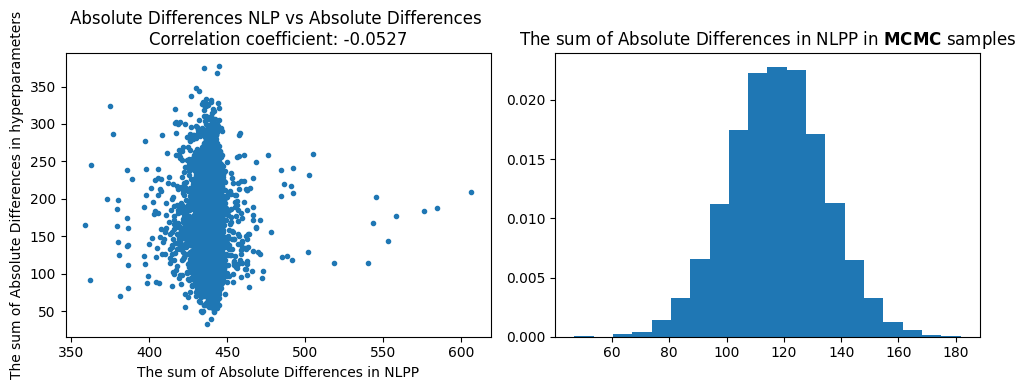

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Scatter plot
axes[0].plot(absolute_differences_nlp, absolute_differences, '.')
axes[0].set_ylabel('The sum of Absolute Differences in hyperparameters')
axes[0].set_xlabel('The sum of Absolute Differences in NLPP')
axes[0].set_title(f'Absolute Differences NLP vs Absolute Differences \nCorrelation coefficient: {correlation:.4f}')

# Histogram
axes[1].hist(random_abs_differences, 20, density=True)
axes[1].set_title(r'The sum of Absolute Differences in NLPP in $\mathbf{MCMC}$ samples')

plt.tight_layout()
plt.show()

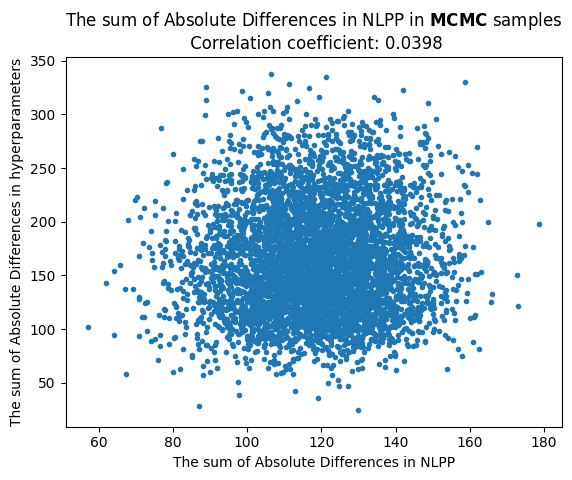

In [38]:
# Calculate the correlation coefficient
correlation2 = np.corrcoef(sum_abs_diff_nlp_random, sum_abs_diff_theta_random)[0, 1]

plt.plot(sum_abs_diff_nlp_random, sum_abs_diff_theta_random, '.')
plt.ylabel('The sum of Absolute Differences in hyperparameters')
plt.xlabel('The sum of Absolute Differences in NLPP')
plt.title(r'The sum of Absolute Differences in NLPP in $\mathbf{MCMC}$ samples' + f' \n Correlation coefficient: {correlation2:.4f}')

plt.show()

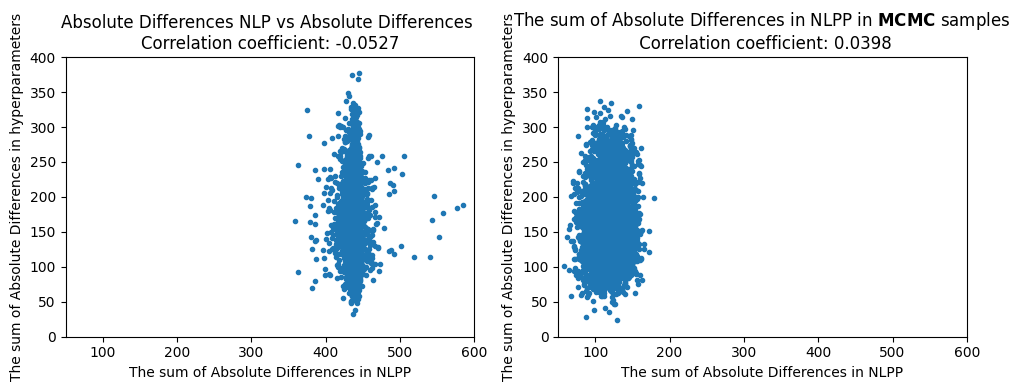

In [34]:
# Calculate the correlation coefficient
correlation = np.corrcoef(absolute_differences_nlp, absolute_differences)[0, 1]
correlation2 = np.corrcoef(sum_abs_diff_nlp_random, sum_abs_diff_theta_random)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Scatter plot
axes[0].plot(absolute_differences_nlp, absolute_differences, '.')
axes[0].set_ylabel('The sum of Absolute Differences in hyperparameters')
axes[0].set_xlabel('The sum of Absolute Differences in NLPP')
axes[0].set_title(f'Absolute Differences NLP vs Absolute Differences \nCorrelation coefficient: {correlation:.4f}')
axes[0].set_xlim(50, 600) 
axes[0].set_ylim(0, 400)

axes[1].plot(sum_abs_diff_nlp_random, sum_abs_diff_theta_random, '.')
axes[1].set_ylabel('The sum of Absolute Differences in hyperparameters')
axes[1].set_xlabel('The sum of Absolute Differences in NLPP')
axes[1].set_title(r'The sum of Absolute Differences in NLPP in $\mathbf{MCMC}$ samples' + f' \n Correlation coefficient: {correlation2:.4f}')
axes[1].set_xlim(50, 600) 
axes[1].set_ylim(0, 400)
plt.tight_layout()
plt.show()